In [8]:
# # ==============================
# # 1. IMPORT LIBRARIES
# # ==============================
# import pandas as pd

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import r2_score, mean_absolute_error
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor


# # ==============================
# # 2. LOAD DATA
# # ==============================
# df = pd.read_csv("House Price Prediction Dataset.csv")

# # ==============================
# # 3. DATA CLEANING
# # ==============================

# # Drop useless column
# df = df.drop('Id', axis=1)

# # No missing values in your dataset (as shown)


# # ==============================
# # 4. ENCODING
# # ==============================

# # One-hot encode categorical columns
# df = pd.get_dummies(df, drop_first=True)


# # ==============================
# # 5. FEATURES & TARGET
# # ==============================
# X = df.drop('Price', axis=1)
# y = df['Price']


# # ==============================
# # 6. TRAIN-TEST SPLIT
# # ==============================
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )


# # ==============================
# # 7. SCALING (ONLY FOR LR)
# # ==============================
# scaler = MinMaxScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


# # ==============================
# # 8. MODELS
# # ==============================

# # Linear Regression
# lr = LinearRegression()
# lr.fit(X_train_scaled, y_train)

# # Random Forest (NO scaling)
# rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
# rf.fit(X_train, y_train)


# # ==============================
# # 9. PREDICTIONS
# # ==============================
# lr_pred = lr.predict(X_test_scaled)
# rf_pred = rf.predict(X_test)


# # ==============================
# # 10. EVALUATION
# # ==============================
# print("\n--- Linear Regression ---")
# print("R2 Score:", r2_score(y_test, lr_pred))
# print("MAE:", mean_absolute_error(y_test, lr_pred))

# print("\n--- Random Forest ---")
# print("R2 Score:", r2_score(y_test, rf_pred))
# print("MAE:", mean_absolute_error(y_test, rf_pred))


# # ==============================
# # 11. FEATURE IMPORTANCE (RF)
# # ==============================
# importances = rf.feature_importances_

# feature_names = X.columns

# importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': importances
# }).sort_values(by='Importance', ascending=False)

# print("\nTop Features:\n", importance_df.head())

In [9]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# plt.imshow(df.corr(), cmap='coolwarm', interpolation='none')
# plt.colorbar()
# plt.xticks(range(len(df.columns)), df.columns, rotation=90)
# plt.yticks(range(len(df.columns)), df.columns)
# plt.title("Correlation Heatmap")
# plt.show()

In [10]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("Housing.csv")

print(df.head())


# ==============================
# 3. DATA PREPROCESSING
# ==============================

# Convert yes/no to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encoding for furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)


# ==============================
# 4. FEATURES & TARGET
# ==============================
X = df.drop('price', axis=1)
y = df['price']


# ==============================
# 5. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# 6. SCALING (for Linear Regression only)
# ==============================
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==============================
# 7. MODEL TRAINING
# ==============================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest (no scaling needed)
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)


# ==============================
# 8. PREDICTIONS
# ==============================
lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)


# ==============================
# 9. EVALUATION
# ==============================
print("\n--- Linear Regression ---")
print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))

print("\n--- Random Forest ---")
print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))


# ==============================
# 10. FEATURE IMPORTANCE
# ==============================
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop Features:\n", importance_df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

--- Linear Regression ---
R2 Score: 0.6529242642153174
MAE: 970043.4039201646

--- Random Forest -

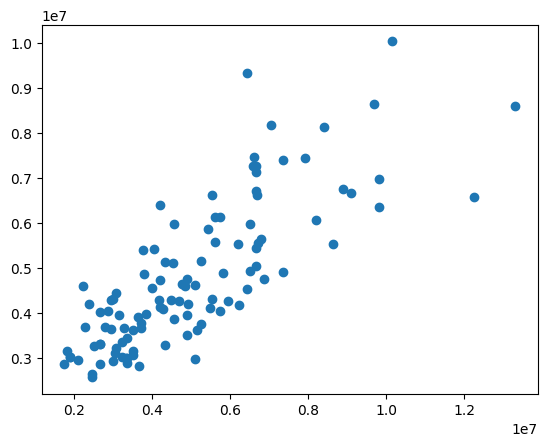

In [11]:
plt.scatter(y_test, rf_pred)